# Tier 2 · Notebook 10 — Attention From Scratch

> **Goal:** build the mechanism that replaced recurrence and powers every modern LLM. From a single query we derive **scaled dot-product attention**, extend to **multi-head attention**, add **causal masking** and **positional encodings** (sinusoidal & RoPE), and *visualize* what attention attends to — all from scratch, verified against PyTorch.

**The core idea: attention is a soft, differentiable dictionary lookup.** A Python dict does a *hard* lookup: given a key, return exactly one value. Attention does a *soft* lookup: given a **query**, compare it to every **key**, and return a **weighted average of all values**, where the weights are how well each key matches the query. Nothing is sequential — every position looks at every other position *simultaneously*. That's the escape from the RNN's step-by-step bottleneck (NB8): no long chain of matrix multiplies for gradients to vanish through, and it's fully parallel.

Three roles, all learned linear projections of the input:
- **Query** $q$ — "what am I looking for?"
- **Key** $k$ — "what do I contain?" (for matching against queries)
- **Value** $v$ — "what do I contribute if attended to?"


## 0. Scaled dot-product attention

Given queries $Q\in\mathbb{R}^{n_q\times d_k}$, keys $K\in\mathbb{R}^{n_k\times d_k}$, values $V\in\mathbb{R}^{n_k\times d_v}$:
$$\text{Attention}(Q,K,V) = \underbrace{\text{softmax}\!\left(\frac{QK^{\mathsf T}}{\sqrt{d_k}}\right)}_{\text{attention weights }A\ (n_q\times n_k)}\,V.$$
Step by step: $QK^{\mathsf T}$ gives every query-key **similarity** (a dot product — big when the vectors align); dividing by $\sqrt{d_k}$ is the crucial scaling (below); softmax over each row turns similarities into a probability distribution (the attention weights); multiplying by $V$ takes the weighted average of values.

**Why divide by $\sqrt{d_k}$?** Each score is a dot product of two $d_k$-dimensional vectors. If their entries are ~unit variance and independent, the dot product $\sum_{i=1}^{d_k} q_i k_i$ has variance $\approx d_k$ — so scores grow like $\sqrt{d_k}$ in magnitude. Large scores push softmax into its saturated regime (one weight ≈ 1, the rest ≈ 0), where gradients are tiny (recall softmax's Jacobian, NB2). Dividing by $\sqrt{d_k}$ rescales the scores back to unit variance, keeping softmax in its responsive range. Let's verify that claim numerically, then build the op.


In [1]:
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0); torch.manual_seed(0)

# demonstrate the variance-growth motivation for the 1/sqrt(d_k) scaling
for dk in [8, 64, 512]:
    q = np.random.randn(100000, dk); k = np.random.randn(100000, dk)
    scores = (q * k).sum(1)                       # dot products
    print(f"d_k={dk:4d}: Var(q·k) = {scores.var():7.1f}  (≈ d_k);  after /sqrt(d_k) = {(scores/np.sqrt(dk)).var():.2f}")


d_k=   8: Var(q·k) =     8.0  (≈ d_k);  after /sqrt(d_k) = 1.00
d_k=  64: Var(q·k) =    64.4  (≈ d_k);  after /sqrt(d_k) = 1.01


d_k= 512: Var(q·k) =   514.9  (≈ d_k);  after /sqrt(d_k) = 1.01


In [2]:
def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x); return e / e.sum(axis=axis, keepdims=True)

def attention(Q, K, V, mask=None):
    dk = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(dk)     # (..., n_q, n_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)          # masked positions -> -inf before softmax
    A = softmax(scores, axis=-1)                       # attention weights
    return A @ V, A

# verify vs torch.nn.functional.scaled_dot_product_attention
nq, nk, dk, dv = 4, 6, 16, 16
Q, K, V = np.random.randn(nq, dk), np.random.randn(nk, dk), np.random.randn(nk, dv)
out_ours, A = attention(Q, K, V)
out_t = F.scaled_dot_product_attention(torch.tensor(Q)[None], torch.tensor(K)[None], torch.tensor(V)[None])[0].numpy()
print("\nscaled dot-product attention vs PyTorch, max abs err =", np.abs(out_ours - out_t).max())
assert np.abs(out_ours - out_t).max() < 1e-10
print("✅ from-scratch attention matches PyTorch")



scaled dot-product attention vs PyTorch, max abs err = 4.440892098500626e-16
✅ from-scratch attention matches PyTorch


**What to notice.** The variance of the raw dot products really does grow as $d_k$ (8→~8, 512→~512), and dividing by $\sqrt{d_k}$ restores it to ~1 regardless of dimension — confirming the scaling's purpose. And our attention matches `F.scaled_dot_product_attention` to machine precision. Every attention weight row sums to 1 (it's a softmax) — each query spends a total "budget" of 1.0 of attention distributed across the keys.


## 1. Visualize attention — the weight matrix

The attention weight matrix $A$ (shape $n_q \times n_k$) *is* the interpretable object: entry $A_{ij}$ = how much query $i$ attends to key $j$. Let's build a tiny self-attention (queries, keys, values all from the same sequence) where some tokens are deliberately similar, and look at the heatmap.


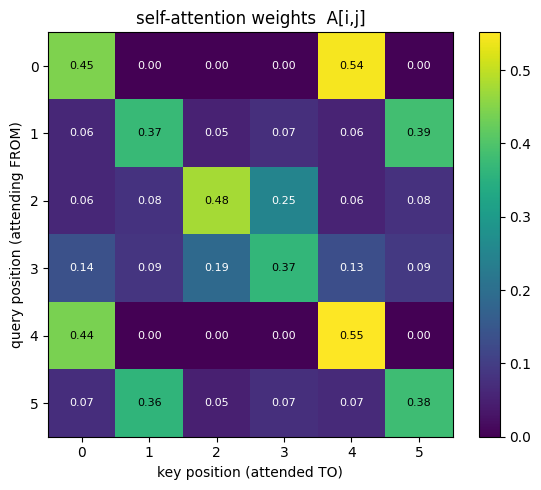

In [3]:
# a toy sequence of 6 tokens in 8-dim space; make tokens 0&4 similar, 1&5 similar
d = 8
seq = np.random.randn(6, d)
seq[4] = seq[0] + 0.1*np.random.randn(d)     # token 4 ~ token 0
seq[5] = seq[1] + 0.1*np.random.randn(d)     # token 5 ~ token 1
_, A = attention(seq, seq, seq)              # self-attention: Q=K=V=seq

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(A, cmap="viridis", vmin=0, vmax=A.max())
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{A[i,j]:.2f}", ha="center", va="center",
                color="white" if A[i,j] < A.max()*0.6 else "black", fontsize=8)
ax.set_xlabel("key position (attended TO)"); ax.set_ylabel("query position (attending FROM)")
ax.set_xticks(range(6)); ax.set_yticks(range(6)); ax.set_title("self-attention weights  A[i,j]")
plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()


**What to notice.** Reading row $i$ tells you where token $i$ looks. Token 0 puts high weight on itself *and* on token 4 (we made them similar), and token 4 reciprocates toward 0 — similar tokens attend to each other, because the dot-product similarity in the scores is large. Every row sums to 1. This heatmap is how you *debug* and *interpret* a transformer: attention maps reveal which words a model links (subject↔verb, pronoun↔antecedent, etc.).


## 2. Causal masking — don't peek at the future

For a **language model** predicting the next token, position $i$ must only attend to positions $\le i$ — it can't see the future it's trying to predict. We enforce this with a **causal mask**: set the scores for $j>i$ to $-\infty$ before softmax, so those weights become exactly 0. The mask is a lower-triangular matrix.


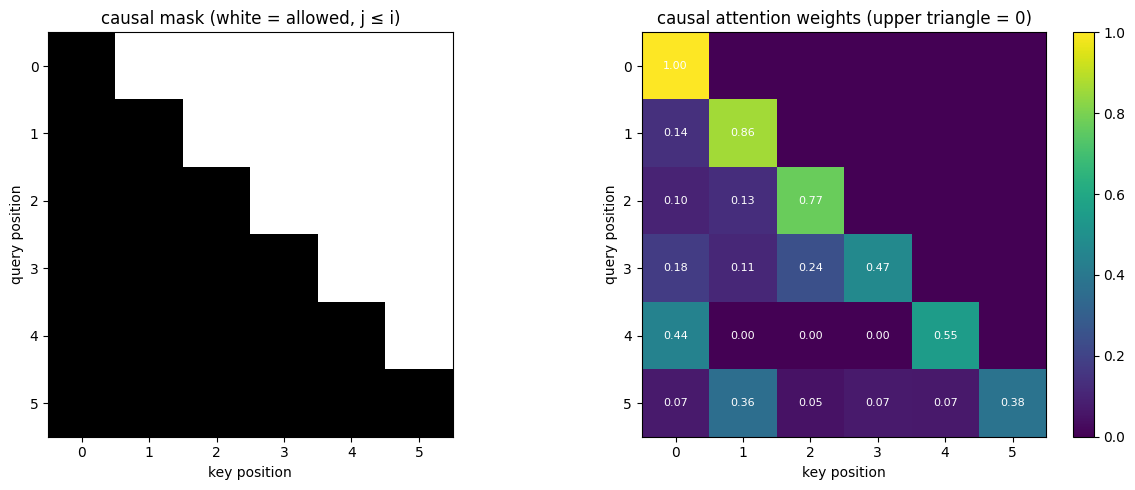

row sums (should all be 1): [1. 1. 1. 1. 1. 1.]


In [4]:
n = 6
causal = np.tril(np.ones((n, n), dtype=bool))     # True where j <= i (allowed)
_, A_causal = attention(seq, seq, seq, mask=causal)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].imshow(causal, cmap="Greys", vmin=0, vmax=1)
ax[0].set_title("causal mask (white = allowed, j ≤ i)")
ax[0].set_xlabel("key position"); ax[0].set_ylabel("query position")
im = ax[1].imshow(A_causal, cmap="viridis")
for i in range(n):
    for j in range(n):
        if A_causal[i,j] > 1e-3:
            ax[1].text(j, i, f"{A_causal[i,j]:.2f}", ha="center", va="center", color="white", fontsize=8)
ax[1].set_title("causal attention weights (upper triangle = 0)")
ax[1].set_xlabel("key position"); ax[1].set_ylabel("query position")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()
print("row sums (should all be 1):", A_causal.sum(1).round(3))


**What to notice.** The upper triangle of the weight matrix is exactly **0** — every position attends only to itself and the past. Row 0 can only attend to position 0 (weight 1.0); row 5 can attend to all six. This single mask is the entire difference between a bidirectional encoder (BERT-style, sees everything) and a causal decoder (GPT-style, the autoregressive language model we'll build in NB11). The masked positions get $-\infty$ scores so `exp(-inf)=0` — they contribute nothing and the remaining weights still sum to 1.


## 3. Multi-head attention

One attention operation gives each position *one* way to mix information. **Multi-head attention** runs $h$ attention operations in parallel, each with its own learned $Q,K,V$ projections into a smaller subspace ($d_k = d_\text{model}/h$), then concatenates and projects the results. Why? Different heads can specialize — one tracks syntax, another tracks coreference, another local context — giving the model multiple "relationship channels" at once, for the same total compute.
$$\text{MHA}(X) = \big[\text{head}_1;\dots;\text{head}_h\big]\,W_O, \quad \text{head}_i = \text{Attention}(XW_Q^i, XW_K^i, XW_V^i).$$
We implement it from scratch and check it against a hand-built PyTorch reference sharing the same weights.


In [5]:
class MultiHeadAttention:
    def __init__(self, d_model, n_heads, seed=0):
        rng = np.random.default_rng(seed)
        self.h, self.d_model = n_heads, d_model
        self.dk = d_model // n_heads
        s = 1/np.sqrt(d_model)
        self.Wq = rng.uniform(-s, s, (d_model, d_model))     # combined projection for all heads
        self.Wk = rng.uniform(-s, s, (d_model, d_model))
        self.Wv = rng.uniform(-s, s, (d_model, d_model))
        self.Wo = rng.uniform(-s, s, (d_model, d_model))
    def __call__(self, X, mask=None):
        n = X.shape[0]
        Q, K, V = X @ self.Wq, X @ self.Wk, X @ self.Wv       # (n, d_model)
        # split into heads: (n, d_model) -> (h, n, dk)
        split = lambda M: M.reshape(n, self.h, self.dk).transpose(1, 0, 2)
        Qh, Kh, Vh = split(Q), split(K), split(V)
        out, self.A = attention(Qh, Kh, Vh, mask=mask)        # per-head attention, (h, n, dk)
        concat = out.transpose(1, 0, 2).reshape(n, self.d_model)
        return concat @ self.Wo

d_model, n_heads, n = 32, 4, 5
mha = MultiHeadAttention(d_model, n_heads)
X = np.random.randn(n, d_model)
out = mha(X)
print("MHA output shape:", out.shape, "| per-head attention shape:", mha.A.shape)

# reference: replicate with torch ops using the same weights (verifies our head-split math)
def torch_mha(X, mha, mask=None):
    Xt = torch.tensor(X)
    Q = Xt @ torch.tensor(mha.Wq); K = Xt @ torch.tensor(mha.Wk); V = Xt @ torch.tensor(mha.Wv)
    n = X.shape[0]
    sp = lambda M: M.reshape(n, mha.h, mha.dk).permute(1,0,2)
    m = None if mask is None else torch.tensor(mask)
    o = F.scaled_dot_product_attention(sp(Q), sp(K), sp(V), attn_mask=m)
    return (o.permute(1,0,2).reshape(n, mha.d_model) @ torch.tensor(mha.Wo)).numpy()

ref = torch_mha(X, mha)
print("multi-head attention vs torch reference, max abs err =", np.abs(out - ref).max())
assert np.abs(out - ref).max() < 1e-10
print("✅ from-scratch multi-head attention matches PyTorch")


MHA output shape: (5, 32) | per-head attention shape: (4, 5, 5)
multi-head attention vs torch reference, max abs err = 2.220446049250313e-16
✅ from-scratch multi-head attention matches PyTorch


**What to notice.** Our multi-head attention matches the PyTorch reference exactly — the reshape/transpose bookkeeping that splits `d_model` into `h` heads and re-assembles them is correct. The per-head attention tensor has shape `(h, n, n)` — one attention map *per head*, which is why transformer interpretability tools show a grid of attention heatmaps (one per head), each having learned a different relationship pattern.


## 4. Positional encodings — attention needs a sense of order

Attention is **permutation-equivariant**: shuffle the input tokens and the outputs shuffle identically — it has *no inherent notion of position*. But "dog bites man" ≠ "man bites dog". So we must **inject position information**. Two important schemes:

**Sinusoidal (original Transformer):** add a fixed vector to each token embedding, where dimension $2i$ uses $\sin(pos/10000^{2i/d})$ and $2i{+}1$ uses $\cos(\dots)$. Different frequencies per dimension give each position a unique, smooth fingerprint, and relative positions are recoverable via trig identities.

**RoPE (Rotary, used in LLaMA/most modern LLMs):** instead of *adding* a position vector, **rotate** the query and key vectors by an angle proportional to their position. Then a dot product $q_m \cdot k_n$ depends only on the *relative* offset $m-n$ — position is encoded multiplicatively and extrapolates better to long sequences. Let's build and visualize both.


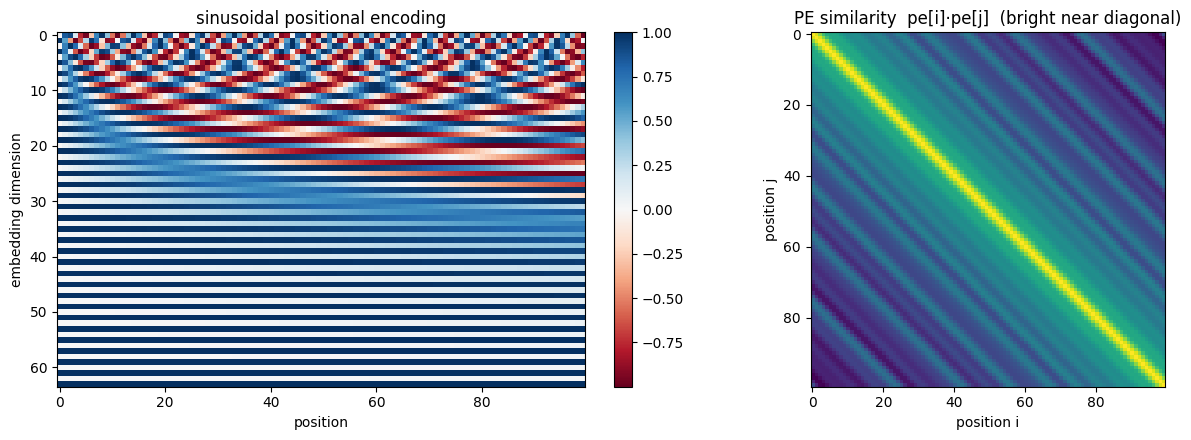

In [6]:
def sinusoidal_pe(n_pos, d):
    pe = np.zeros((n_pos, d))
    pos = np.arange(n_pos)[:, None]
    div = np.exp(np.arange(0, d, 2) * (-np.log(10000.0) / d))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

pe = sinusoidal_pe(100, 64)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
im = ax[0].imshow(pe.T, cmap="RdBu", aspect="auto")
ax[0].set_title("sinusoidal positional encoding"); ax[0].set_xlabel("position"); ax[0].set_ylabel("embedding dimension")
plt.colorbar(im, ax=ax[0], fraction=0.046)
# similarity between position encodings: nearby positions are more similar (smooth)
sim = pe @ pe.T
ax[1].imshow(sim, cmap="viridis"); ax[1].set_title("PE similarity  pe[i]·pe[j]  (bright near diagonal)")
ax[1].set_xlabel("position i"); ax[1].set_ylabel("position j")
plt.tight_layout(); plt.show()


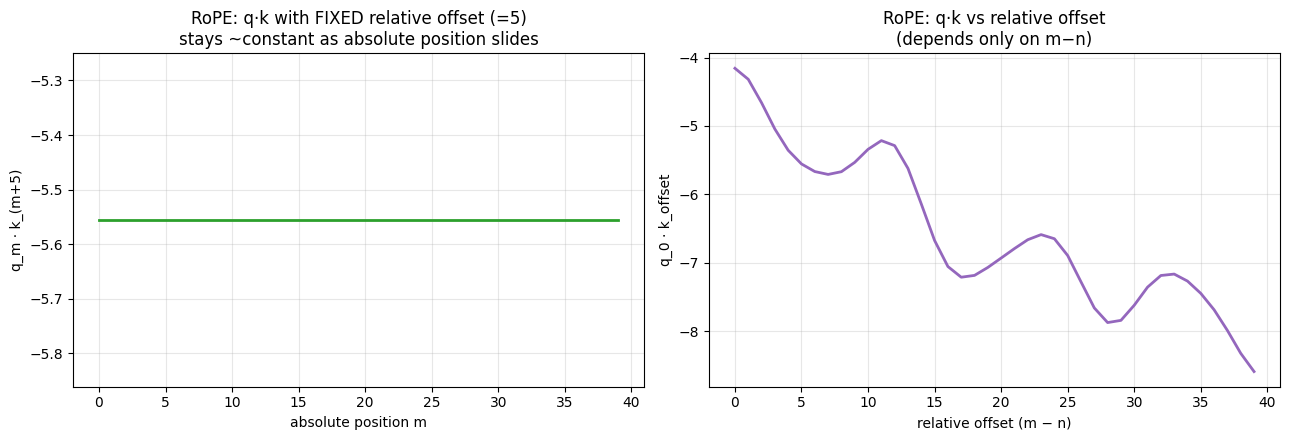

In [7]:
def rope(x, positions):
    """Apply rotary position embedding to x (n, d). Rotates dim-pairs by position*freq."""
    n, d = x.shape
    freqs = 1.0 / (10000 ** (np.arange(0, d, 2) / d))       # (d/2,)
    ang = positions[:, None] * freqs[None, :]               # (n, d/2)
    cos, sin = np.cos(ang), np.sin(ang)
    x1, x2 = x[:, 0::2], x[:, 1::2]
    out = np.empty_like(x)
    out[:, 0::2] = x1 * cos - x2 * sin                      # rotate each (x1,x2) pair
    out[:, 1::2] = x1 * sin + x2 * cos
    return out

# key property: after RoPE, q·k depends only on the RELATIVE position offset
d = 32
q = np.random.randn(d); k = np.random.randn(d)
offsets = np.arange(0, 40)
# fix relative offset = 5, slide the absolute position; dot product should stay ~constant
dots_rel5 = []
for m in range(40):
    qm = rope(q[None], np.array([m]))[0]
    kn = rope(k[None], np.array([m+5]))[0]
    dots_rel5.append(qm @ kn)
# vs varying the relative offset from a fixed base
dots_vary = []
for off in offsets:
    qm = rope(q[None], np.array([0]))[0]
    kn = rope(k[None], np.array([off]))[0]
    dots_vary.append(qm @ kn)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(dots_rel5, lw=2, color="tab:green"); ax[0].set_title("RoPE: q·k with FIXED relative offset (=5)\nstays ~constant as absolute position slides")
ax[0].set_xlabel("absolute position m"); ax[0].set_ylabel("q_m · k_(m+5)"); ax[0].grid(alpha=0.3)
ax[1].plot(offsets, dots_vary, lw=2, color="tab:purple"); ax[1].set_title("RoPE: q·k vs relative offset\n(depends only on m−n)")
ax[1].set_xlabel("relative offset (m − n)"); ax[1].set_ylabel("q_0 · k_offset"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


**What to notice.** *Left pair (sinusoidal):* each position gets a unique multi-frequency fingerprint (left heatmap), and the similarity matrix (right) is brightest near the diagonal — nearby positions have similar encodings, so the model gets a smooth sense of "close vs far." *RoPE (bottom):* with the relative offset held at 5, the query-key dot product stays essentially **constant** as we slide the absolute position (left) — proving RoPE encodes *relative* position; and the dot product varies smoothly with the *relative* offset (right). This relative-position property is why RoPE generalizes to longer sequences than it was trained on, and why it's in LLaMA, GPT-NeoX, and most current LLMs.

## 5. What you built / learned
- **Scaled dot-product attention** — soft dictionary lookup; the $\sqrt{d_k}$ scaling derived from variance growth; verified vs PyTorch.
- **Attention weight visualization** — the interpretable $n\times n$ map of who-attends-to-whom.
- **Causal masking** — the one change that makes attention autoregressive (GPT-style).
- **Multi-head attention** — parallel attention subspaces; verified vs PyTorch.
- **Positional encodings** — sinusoidal (additive) and RoPE (rotary, relative) — since attention itself is order-blind.

You now have every component of a transformer *block* except the feed-forward and residual wiring. NB11 assembles them into GPT.

## 6. Exercises
1. **Attention entropy.** Compute the entropy of each attention row. When is a head "focused" (low entropy) vs "diffuse" (high entropy)? Plot it over training.
2. **Remove the scaling.** Drop the $1/\sqrt{d_k}$ and watch attention weights saturate (one-hot) at large $d_k$; measure the gradient magnitude.
3. **Cross-attention.** Make $Q$ come from one sequence and $K,V$ from another (encoder-decoder attention). Verify shapes and meaning.
4. **KV vs Q count.** Implement grouped-query attention (fewer K/V heads than Q heads) — the memory-saving trick in modern LLMs (preview of NB14).
5. **Learned vs sinusoidal PE.** Train a tiny model with each and compare; when does the fixed encoding suffice?
6. **RoPE derivation.** Show algebraically that $\text{RoPE}(q,m)\cdot\text{RoPE}(k,n)$ depends only on $m-n$ (2-D rotation dot product).

## 7. Interview / residency framing
- *"Explain attention."* → soft dictionary lookup: score query against all keys, softmax to weights, weighted sum of values; $QK^T/\sqrt{d_k}$ then $\cdot V$.
- *"Why divide by $\sqrt{d_k}$?"* → dot-product variance grows as $d_k$; without scaling, softmax saturates and gradients vanish.
- *"Why multi-head?"* → multiple relationship subspaces in parallel; heads specialize (syntax, coreference, locality) at the same compute.
- *"How is a decoder made autoregressive?"* → causal mask: $-\infty$ scores for future positions before softmax.
- *"Sinusoidal vs RoPE?"* → sinusoidal adds an absolute-position vector; RoPE rotates Q/K so the dot product depends on relative position — better length extrapolation, used in modern LLMs.
- *"Attention vs recurrence?"* → attention connects all positions in one parallel op (no vanishing through time), at $O(n^2)$ cost (the tradeoff we address in NB16).

---
**Next:** *Tier 2 · Notebook 11 — GPT from scratch* (the flagship): assemble attention + feed-forward + residual + LayerNorm into a decoder-only transformer, and train it to generate text.


## 📚 References & papers

This notebook reproduces / builds on:

- **Attention Is All You Need** — Vaswani et al. (2017), arXiv:1706.03762. Scaled dot-product & multi-head attention, sinusoidal positions.
- **RoFormer: Enhanced Transformer with Rotary Position Embedding (RoPE)** — Su et al. (2021), arXiv:2104.09864.
- **Train Short, Test Long: Attention with Linear Biases (ALiBi)** — Press, Smith & Lewis (2021), arXiv:2108.12409.